# Rotterdam Intersection Photo Filter

Filters all 706,743 panoramic photos down to those within 55m of a road intersection
inside the Rotterdam ring. Result is ~170,000 photos (~1.7TB).

**Why 55m:** covers the full approach zone to an intersection — photos closer than
this are likely still in the intersection itself; further away they lose useful context.
The directional filter was dropped because photos are full 360° panoramas — the
intersection is always visible regardless of which direction the car was driving.

**Input files:**
- `D:\rotterdam_aiis_2025\vault-production\vault_v1\Recording.csv` — full photo index (706,743 rows, tab-delimited)
- `data/processed/intersections_merged.gpkg` — merged intersections (from notebook 01)
- `data/processed/rotterdam_boundary.gpkg` — Rotterdam boundary (from notebook 00)

**Output files:**
- `data/processed/selected_photos_near_intersections.csv` — filtered photo list (~170k rows)

**Depends on:** notebook 00 must be run first.

**Coordinate system:** RD New (EPSG:28992) — meters-based Dutch projection.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os

# Base project directory — all other project paths are relative to this
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\intersections"

# --- Dataset selection ---
# "tudelft_2024" : new TU Delft 2024 dataset (image_index.csv, 4 directional images per location)
# "legacy"       : old AIIS dataset (Recording.csv, one 360° equirectangular panorama per location)
DATASET = "tudelft_2024"

# Root of the photo vault — same base path for both datasets, different internal structure
VAULT_DIR = r"D:\rotterdam_aiis_2025\vault-production\vault_v1"

# Input CSV path depends on the dataset
if DATASET == "tudelft_2024":
    # New dataset: comma-delimited index with H3 grid hierarchy and per-direction headings
    CSV_PATH = os.path.join(VAULT_DIR, "image_index.csv")
else:
    # Legacy dataset: tab-delimited, one 360° panorama per row with a single Pan angle
    HDD_CSV_PATH   = os.path.join(VAULT_DIR, "Recording.csv")
    LOCAL_CSV_PATH = os.path.join(PROJECT_DIR, "data", "raw", "Recording.csv")
    CSV_PATH = HDD_CSV_PATH if os.path.exists(HDD_CSV_PATH) else LOCAL_CSV_PATH

print(f"Dataset  : {DATASET}")
print(f"CSV path : {CSV_PATH}")

# Intersections and boundary prepared by notebook 01
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
BOUNDARY_PATH      = os.path.join(PROJECT_DIR, "data", "processed", "rotterdam_boundary.gpkg")

# Output path
OUTPUT_CSV = os.path.join(PROJECT_DIR, "data", "processed", "selected_photos_near_intersections.csv")

# Filter parameters
# BUFFER_METERS is the fallback outer radius used when the intersections file does not
# carry a per-intersection max_dist_m column. When max_dist_m is available (written by
# notebook 01 as cluster_radius + CAPTURE_BUFFER_M), that value is used per intersection
# instead so that large merged junctions get a wider capture zone.
BUFFER_METERS = 55  # fallback outer radius (metres) if max_dist_m not present

# Safety margin added on top of max_dist_m (or BUFFER_METERS) to avoid floating-point
# edge artefacts: photos landing exactly on the buffer polygon boundary can fall just
# inside or outside depending on Shapely's polygon approximation. A small margin
# ensures they are always captured without meaningfully expanding the search zone.
BUFFER_MARGIN_M = 5  # metres

# Minimum distance: exclude photos shot from inside the intersection itself
INNER_BUFFER_METERS = 5  # metres

CRS_RD = "EPSG:28992"  # RD New — Dutch national projection in metres

## 1. Load photo coordinates

In [ ]:
if DATASET == "tudelft_2024":
    # New TU Delft 2024 dataset: comma-delimited, one row per camera location.
    # Each row has 4 directional image paths (front/back/left/right) and their headings.
    df = pd.read_csv(CSV_PATH)
    # Rename to the legacy column names used throughout the rest of the pipeline,
    # so downstream cells and notebooks don't need separate branches.
    df = df.rename(columns={
        "image_id":  "Filename",
        "x":         "X/Long",
        "y":         "Y/Lat",
        "trip_time": "Timestamp",
    })
    print(f"TU Delft 2024 dataset loaded: {len(df):,} camera locations")
else:
    # Legacy AIIS dataset: tab-delimited, one 360° panorama per row
    df = pd.read_csv(CSV_PATH, sep="\t")
    df.columns = df.columns.str.strip()
    print(f"Legacy AIIS dataset loaded: {len(df):,} photos")

print(df.shape)
df.head()

In [ ]:
# Build GeoDataFrame from RD New coordinates
photos_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X/Long"], df["Y/Lat"]),
    crs=CRS_RD
)

# Add the full HDD path to the canonical image for each camera location.
# For TU Delft 2024: each row has 4 directional images; store the front-camera image
# as the canonical filepath. Notebook 04 can pick a specific direction using the
# heading columns when selecting the best approach image per leg.
# For legacy: a single 360° panorama per row in a flat JPEG/ folder.
if DATASET == "tudelft_2024":
    images_root = os.path.join(VAULT_DIR, "images")
    photos_gdf["filepath"] = photos_gdf["img_front"].apply(
        lambda p: os.path.join(images_root, p.replace("/", os.sep))
    )
    # Use heading_front as the Pan angle (compass bearing the front camera faces).
    # This is the closest equivalent to the legacy single-lens Pan value and is used
    # downstream to compute u_deg. Replaced automatically when 360° panoramas arrive.
    photos_gdf["Pan"] = photos_gdf["heading_front"]
else:
    # Legacy: all files flat in JPEG/ subfolder with .jpeg extension.
    # Pan is already in df from Recording.csv.
    photos_gdf["filepath"] = os.path.join(VAULT_DIR, "JPEG") + "\\" + photos_gdf["Filename"] + ".jpeg"

print(f"Total photo locations: {len(photos_gdf):,}")
photos_gdf[["Filename", "X/Long", "Y/Lat", "Pan", "filepath"]].head()

## 2. Load Rotterdam boundary and intersections from file

Rotterdam boundary loaded.
Intersections loaded: 4,715


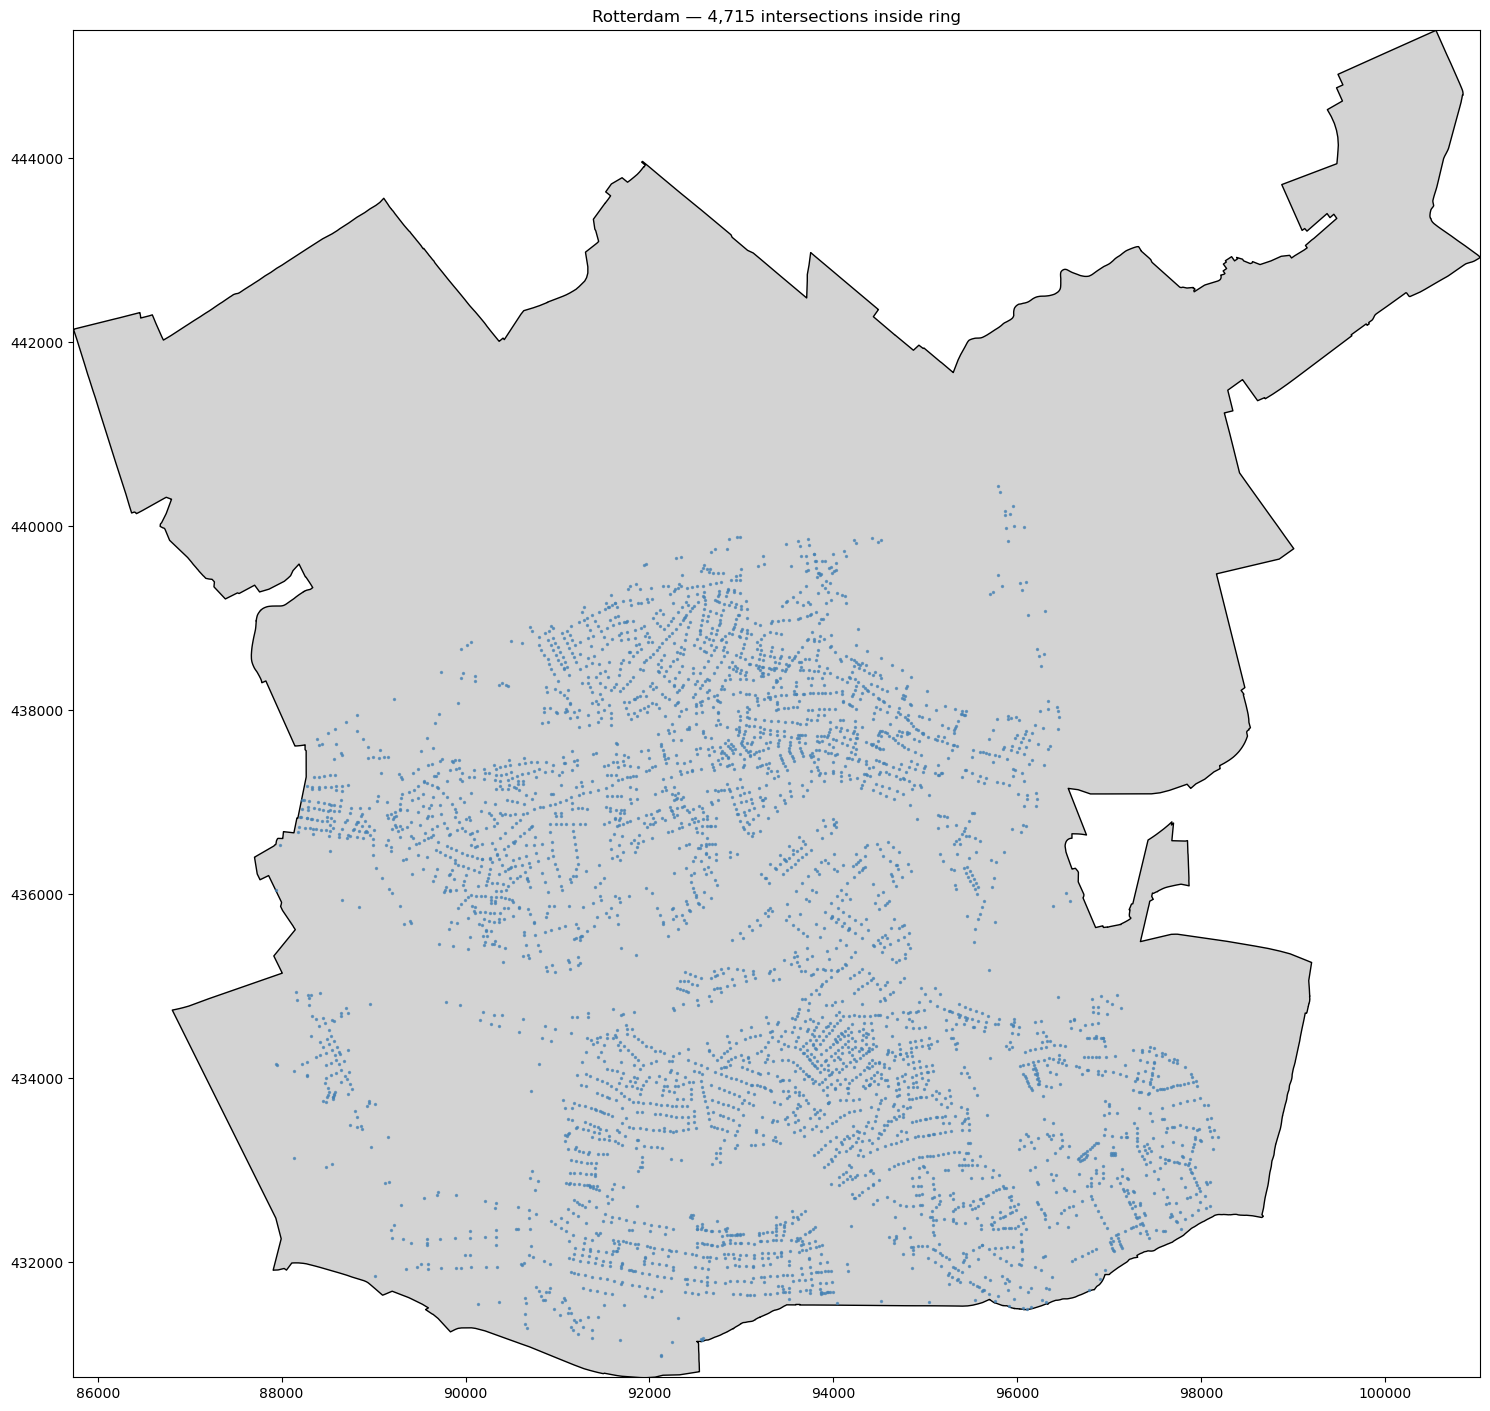

In [23]:
# Load boundary and intersections saved by notebook 00
rotterdam     = gpd.read_file(BOUNDARY_PATH)
intersections = gpd.read_file(INTERSECTIONS_PATH)

print(f"Rotterdam boundary loaded.")
print(f"Intersections loaded: {len(intersections):,}")

# Get the bounding box of Rotterdam to use as axis limits in all plots
minx, miny, maxx, maxy = rotterdam.total_bounds

# Quick plot to verify the data looks correct
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
intersections.plot(ax=ax, color="steelblue", markersize=2, alpha=0.7)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title(f"Rotterdam — {len(intersections):,} intersections inside ring")
plt.tight_layout()
plt.show()

## 4. Buffer intersections — per-intersection annular ring

Each intersection gets an annular buffer: outer disk minus inner disk (INNER_BUFFER_METERS).

The outer radius comes from the `max_dist_m` column if present — written by notebook 01 as
`cluster_radius + CAPTURE_BUFFER_M`. Large merged junctions (dual carriageways) therefore
get a wider capture zone automatically. A small `BUFFER_MARGIN_M` is added on top to avoid
floating-point edge artefacts where photos on the exact boundary are missed by the sjoin.

If `max_dist_m` is not in the file, all intersections fall back to the fixed `BUFFER_METERS`.

In [24]:
print("Creating buffers...")
buffered = intersections[["geometry"]].copy()

# Use per-intersection outer radius if max_dist_m is available; otherwise use the fixed fallback.
# max_dist_m = cluster_radius + CAPTURE_BUFFER_M, computed in notebook 01.
# Adding BUFFER_MARGIN_M ensures photos right at the boundary edge are not missed by the sjoin.
if "max_dist_m" in intersections.columns:
    outer_radii = intersections["max_dist_m"] + BUFFER_MARGIN_M
    print(f"Using per-intersection outer radii from max_dist_m "
          f"(range: {outer_radii.min():.1f}–{outer_radii.max():.1f}m, "
          f"margin: +{BUFFER_MARGIN_M}m)")
else:
    outer_radii = BUFFER_METERS + BUFFER_MARGIN_M
    print(f"max_dist_m not found — using fixed outer radius: {outer_radii}m")

# Annular buffer: outer disk minus inner disk.
# Photos within INNER_BUFFER_METERS of the intersection centre are excluded
# because they are shot from inside the intersection itself.
buffered["geometry"] = (
    intersections.geometry.buffer(outer_radii)
    .difference(intersections.geometry.buffer(INNER_BUFFER_METERS))
)

# Keep intersection centre coordinates for bearing calculation
buffered["inter_x"] = intersections.geometry.x
buffered["inter_y"] = intersections.geometry.y
buffered = buffered.reset_index(drop=True)

print(f"Done. {len(buffered):,} intersection buffers created.")

Creating buffers...
Using per-intersection outer radii from max_dist_m (range: 35.0–66.8m, margin: +5m)
Done. 4,715 intersection buffers created.


## 5. Visualise — Rotterdam boundary + intersection buffers

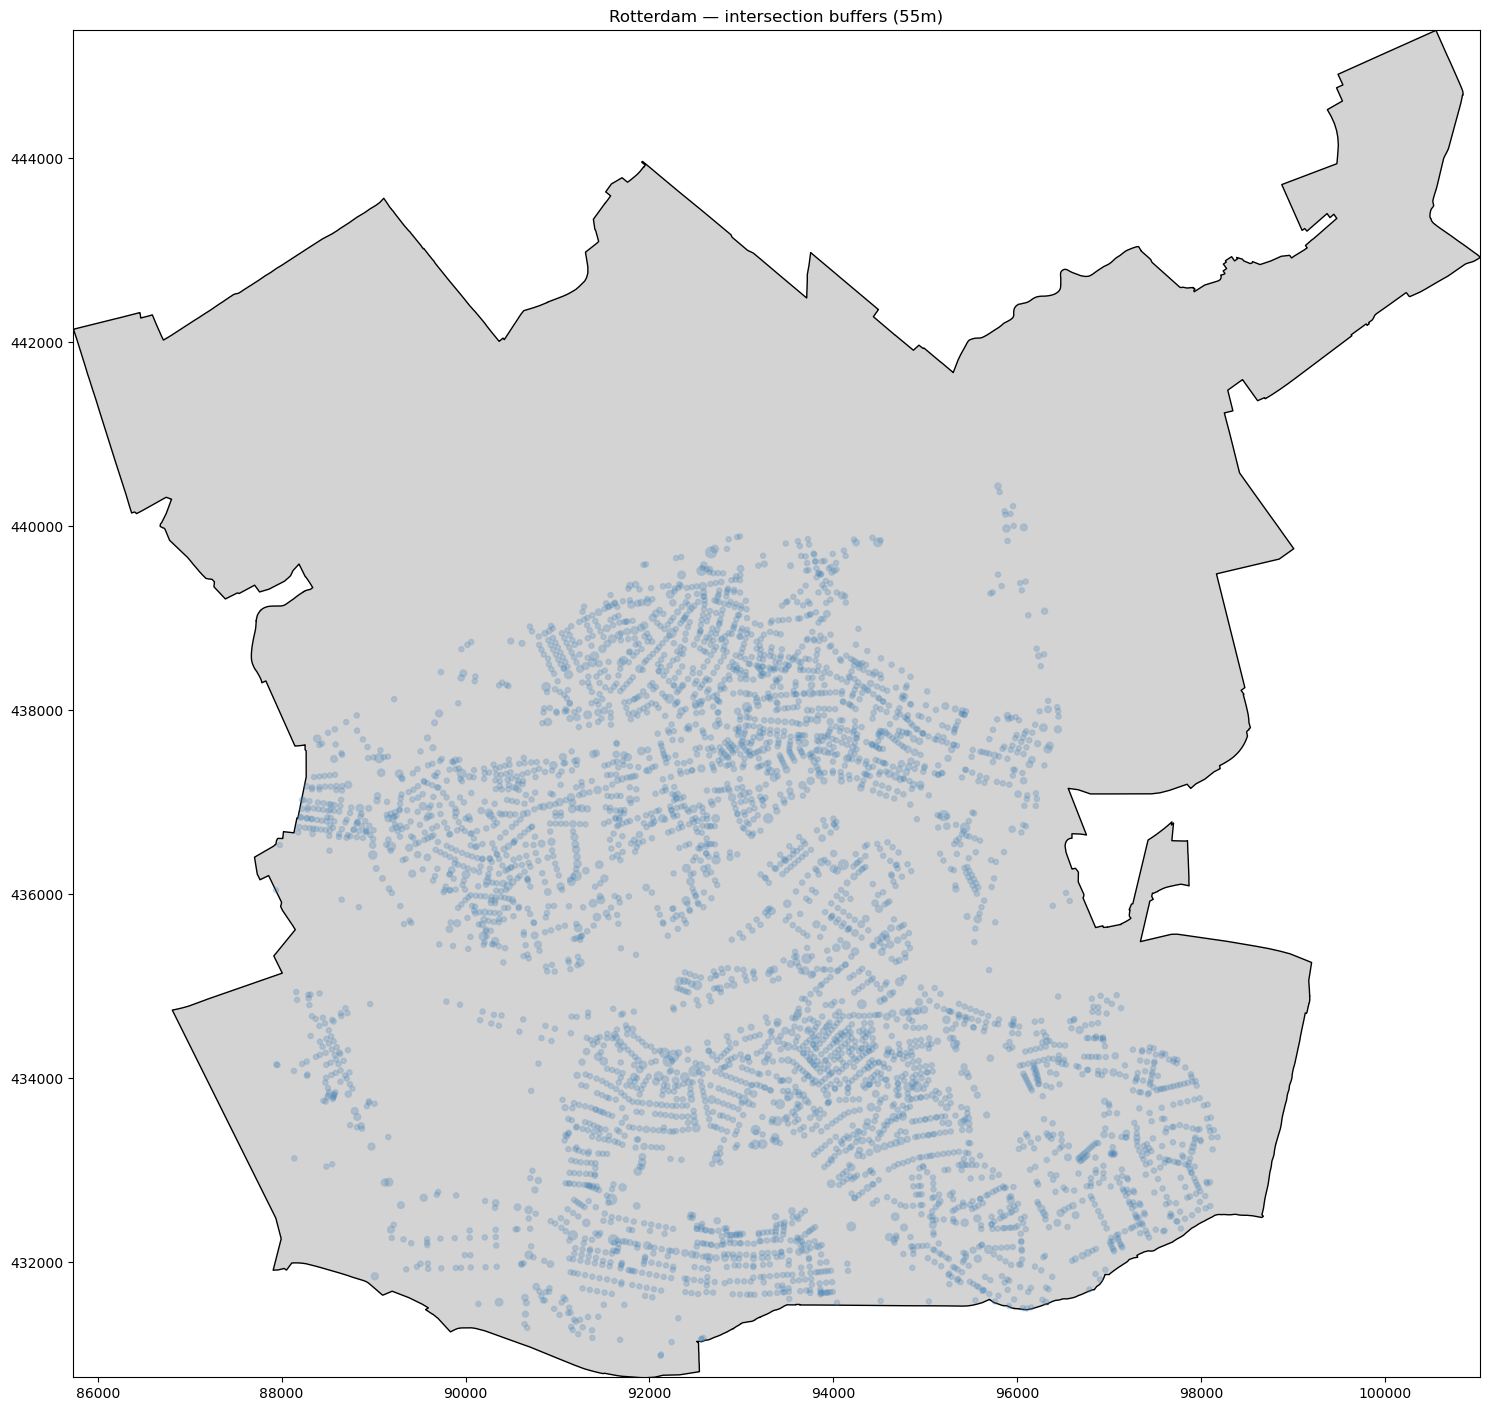

In [25]:
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
buffered.plot(ax=ax, color="steelblue", alpha=0.3)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title(f"Rotterdam — intersection buffers ({BUFFER_METERS}m)")
plt.tight_layout()
plt.show()

## 6. Select photos within 55m of an intersection

In [26]:
print("Running spatial filter...")

CHUNK_SIZE = 10_000
n_photos   = len(photos_gdf)
n_chunks   = max(1, n_photos // CHUNK_SIZE)

matched_indices = []
for i in range(n_chunks):
    start = i * CHUNK_SIZE
    end   = min(start + CHUNK_SIZE, n_photos)
    chunk = photos_gdf.iloc[start:end]

    # Find all photos whose point falls within any intersection buffer.
    # sjoin uses an R-tree spatial index — much faster than .within() on a merged polygon.
    result = gpd.sjoin(chunk, buffered, how="inner", predicate="within")
    matched_indices.append(result.index)

    if (i + 1) % 10 == 0 or (i + 1) == n_chunks:
        pct = (i + 1) / n_chunks * 100
        print(f"  {i+1}/{n_chunks} chunks done ({pct:.0f}%)")

# Combine all matched indices and drop duplicates (a photo can match multiple buffers)
all_matched = pd.Index(np.concatenate(matched_indices)).unique()
selected = photos_gdf.loc[all_matched].copy()

max_outer = outer_radii.max() if hasattr(outer_radii, "max") else outer_radii
print(f"\nPhotos within per-intersection buffer (max {max_outer:.0f}m): {len(selected):,}")
print(f"Total photos:                                                   {len(photos_gdf):,}")
print(f"Selection rate:                                                 {len(selected)/len(photos_gdf)*100:.1f}%")

Running spatial filter...
  10/70 chunks done (14%)
  20/70 chunks done (29%)
  30/70 chunks done (43%)
  40/70 chunks done (57%)
  50/70 chunks done (71%)
  60/70 chunks done (86%)
  70/70 chunks done (100%)

Photos within per-intersection buffer (max 67m): 124,395
Total photos:                                                   706,743
Selection rate:                                                 17.6%


## 7. Visualise selected photos on the map

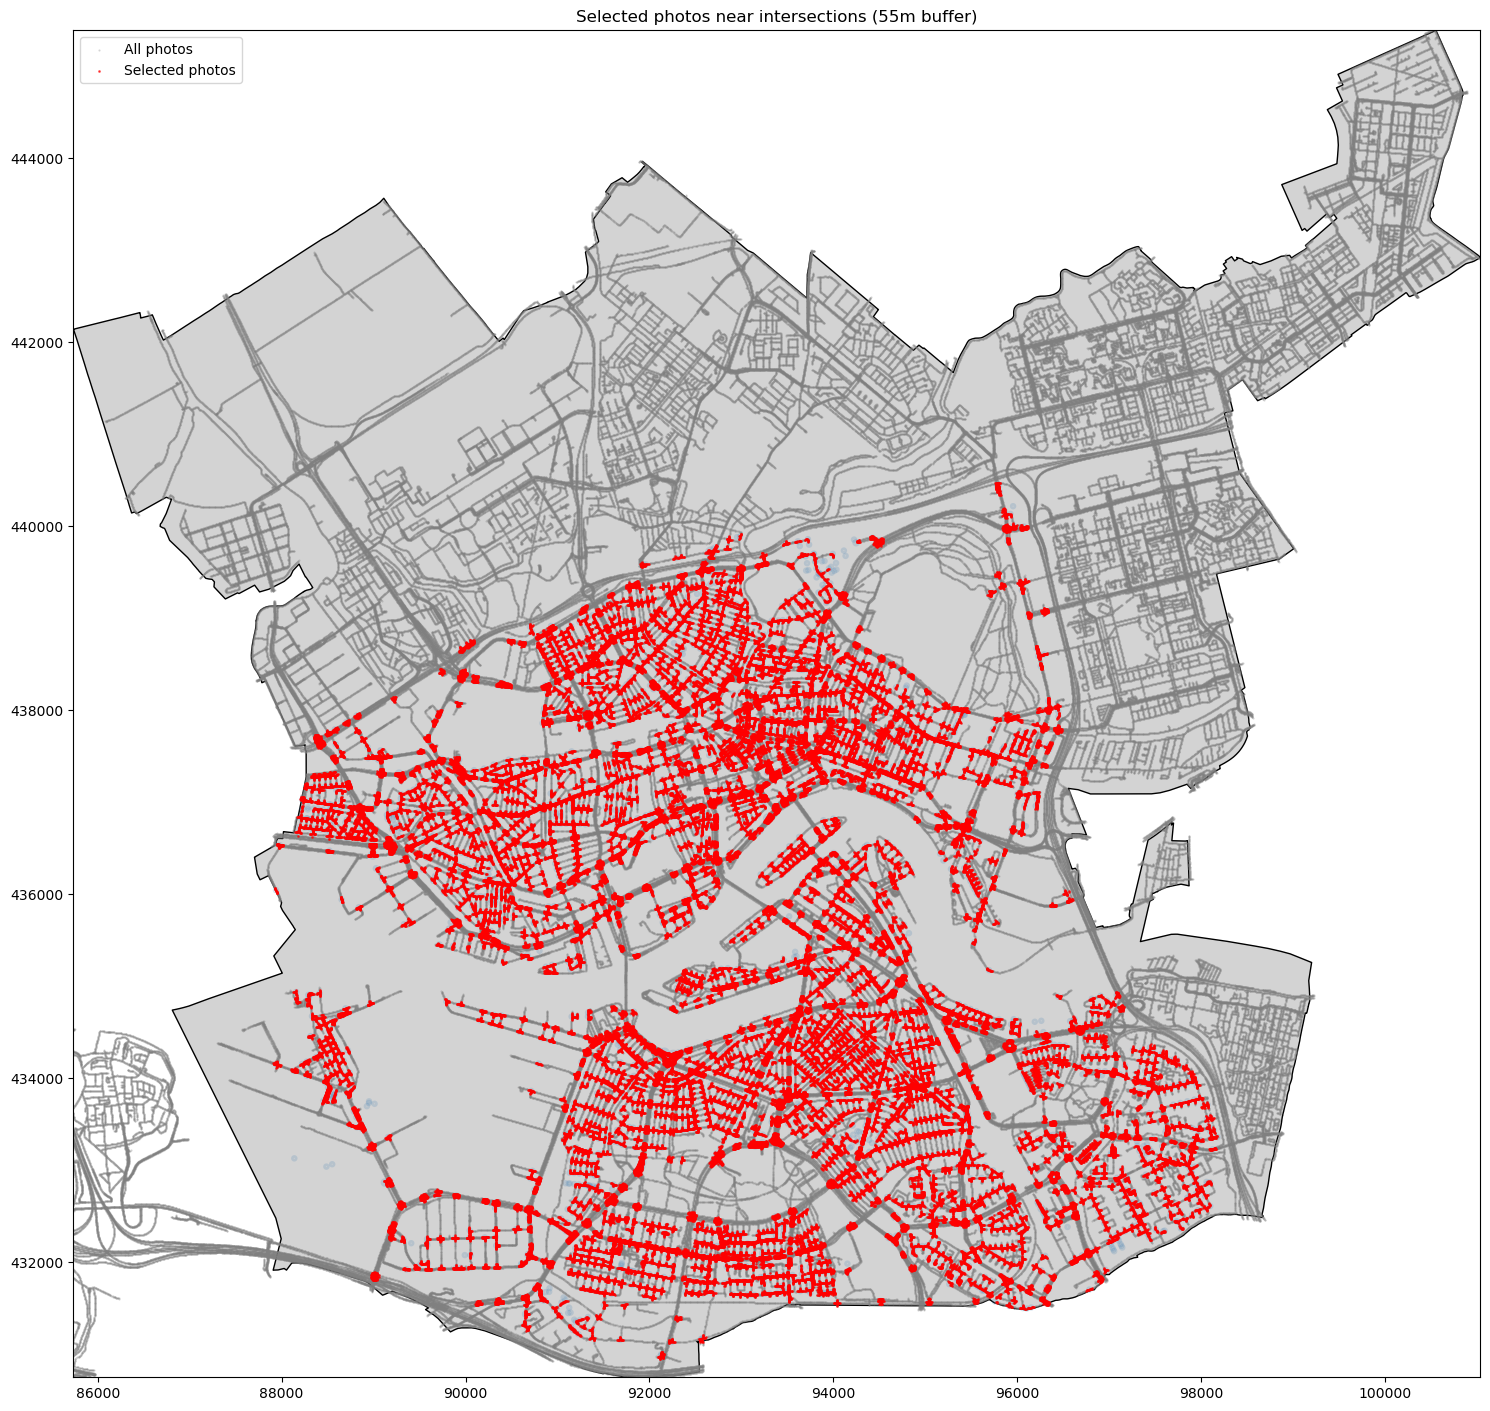

In [27]:
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
buffered.plot(ax=ax, color="steelblue", alpha=0.2)
photos_gdf.plot(ax=ax, color="grey", markersize=0.3, alpha=0.3, label="All photos")
selected.plot(ax=ax, color="red", markersize=1, alpha=0.6, label="Selected photos")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.legend()
ax.set_title(f"Selected photos near intersections ({BUFFER_METERS}m buffer)")
plt.tight_layout()
plt.show()

## 8. Export result

In [ ]:
# Save CSV with filename, path, coordinates, heading, and (for new dataset) direction columns.
# Pan is included in the core columns so that notebook 04 does not need to re-read
# the source recording file and has no dataset-specific branching of its own.
export_cols = ["Filename", "filepath", "X/Long", "Y/Lat", "Pan", "Timestamp"]

# For TU Delft 2024, also export the per-direction paths and heading angles.
# Notebook 04 uses these to pick the best directional image per approach leg.
if DATASET == "tudelft_2024":
    direction_cols = [c for c in [
        "img_front", "img_back", "img_left", "img_right",
        "heading_front", "heading_right", "heading_back", "heading_left",
        "H3_8", "H3_9", "H3_10",
    ] if c in selected.columns]
    export_cols = export_cols + direction_cols

selected[export_cols].to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(selected):,} rows to: {OUTPUT_CSV}")
selected[export_cols].head()